# MLP Name Generator

**Barkeep Protocol — Act 1, Week 2, Days 3–4**

Bengio et al. (2003) applied to character-level name generation.
Architecture: embedding table → concat context → tanh hidden layer → logits → cross-entropy.

In [1]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
accelerator = "xpu" if torch.xpu.is_available() else "cpu"

## Data

In [3]:
words = open("Names.txt", "r").read().splitlines()

In [4]:
letters = sorted(set("".join(words)))

ltr_to_idx = {ltr: idx + 1 for idx, ltr in enumerate(letters)}
ltr_to_idx["."] = 0

idx_to_ltr = {idx: ltr for ltr, idx in ltr_to_idx.items()}

VOCAB_SIZE = len(ltr_to_idx)
print(f"Vocabulary size: {VOCAB_SIZE} | Words: {len(words):,}")

Vocabulary size: 27 | Words: 32,033


In [5]:
max(len(word) for word in words)

15

In [6]:
block_size = 8

def build_dataset(words, accelerator):
    Xs, Ys = [], []

    for word in words:
        context = [0] * block_size

        for ltr in word + '.':
            idx = ltr_to_idx[ltr]
            Xs.append(context)
            Ys.append(idx)
            context = context[1:] + [idx]

    return (
        torch.tensor(Xs, dtype=torch.int, device=accelerator),
        torch.tensor(Ys, dtype=torch.long, device=accelerator),
    )

In [7]:
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

trn_inputs,  trn_outputs  = build_dataset(words[:n1], accelerator)
val_inputs,  val_outputs  = build_dataset(words[n1:n2], accelerator)
test_inputs, test_outputs = build_dataset(words[n2:], accelerator)

for split, t in [("train", trn_inputs), ("val", val_inputs), ("test", test_inputs)]:
    print(f"{split:>5}: {t.shape[0]:>7,} examples")

train: 182,625 examples
  val:  22,655 examples
 test:  22,866 examples


## Model

In [8]:
sampler = torch.Generator().manual_seed(42)

embedding_dimensionality = 30
d1 = block_size * embedding_dimensionality
d2 = 300

embedding_matrix = (torch.randn((VOCAB_SIZE, embedding_dimensionality), generator=sampler) * 0.1).to(accelerator)
weights_1        = (torch.randn((d1, d2),                               generator=sampler) * 0.1).to(accelerator)
bias_1           = (torch.zeros(d2)).to(accelerator)
weights_2        = (torch.randn((d2, VOCAB_SIZE),                       generator=sampler) * 0.1).to(accelerator)
bias_2           = (torch.zeros(VOCAB_SIZE)).to(accelerator)

parameters = [embedding_matrix, weights_1, bias_1, weights_2, bias_2]
for p in parameters:
    p.requires_grad = True

print(f"Parameters: {sum(p.nelement() for p in parameters):,}")

Parameters: 81,237


In [9]:
def embed_inputs(inputs):
    return embedding_matrix[inputs]

## Training

In [10]:
total_steps = 17500
lr_start    = 0.5
lr_end      = 0.01

lr_per_itrn   = []
loss_per_itrn = []
val_losses    = []
val_steps     = []

torch.xpu.synchronize()
t0 = time.time()

for turn in range(total_steps):
    idx = torch.randint(0, trn_inputs.shape[0], (4096,), device=accelerator)

    embedded_inputs = embed_inputs(trn_inputs[idx])
    hidden_layer    = torch.tanh(embedded_inputs.view(-1, d1) @ weights_1 + bias_1)
    logits          = hidden_layer @ weights_2 + bias_2
    loss            = torch.nn.functional.cross_entropy(logits, trn_outputs[idx])

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lr_end + 0.5 * (lr_start - lr_end) * (1 + np.cos( np.pi * turn / total_steps))
    for p in parameters:
        p.data += -lr * p.grad

    lr_per_itrn.append(lr)
    loss_per_itrn.append(loss.item())

    if (turn + 1) % 1750 == 0:
        with torch.no_grad():
            emb      = embed_inputs(val_inputs)
            h        = torch.tanh(emb.view(-1, d1) @ weights_1 + bias_1)
            val_loss = torch.nn.functional.cross_entropy(h @ weights_2 + bias_2, val_outputs)
        val_losses.append(val_loss.item())
        val_steps.append(turn + 1)
        print(f"  step {turn + 1:>7,} | val {val_loss.item():.4f} | lr {lr:.4f}")

torch.xpu.synchronize()
elapsed = time.time() - t0

print(f"xpu: {elapsed}")

  step   1,750 | val 2.1674 | lr 0.4880
  step   3,500 | val 2.0941 | lr 0.4532
  step   5,250 | val 2.0517 | lr 0.3990
  step   7,000 | val 2.0259 | lr 0.3308
  step   8,750 | val 2.0214 | lr 0.2550
  step  10,500 | val 2.0147 | lr 0.1793
  step  12,250 | val 2.0159 | lr 0.1110
  step  14,000 | val 2.0161 | lr 0.0568
  step  15,750 | val 2.0169 | lr 0.0220
  step  17,500 | val 2.0172 | lr 0.0100
xpu: 429.32058477401733


## Visualisation

In [11]:
import sys
sys.path.insert(0, '..')
import barkeep_style as bks
bks.apply_style()

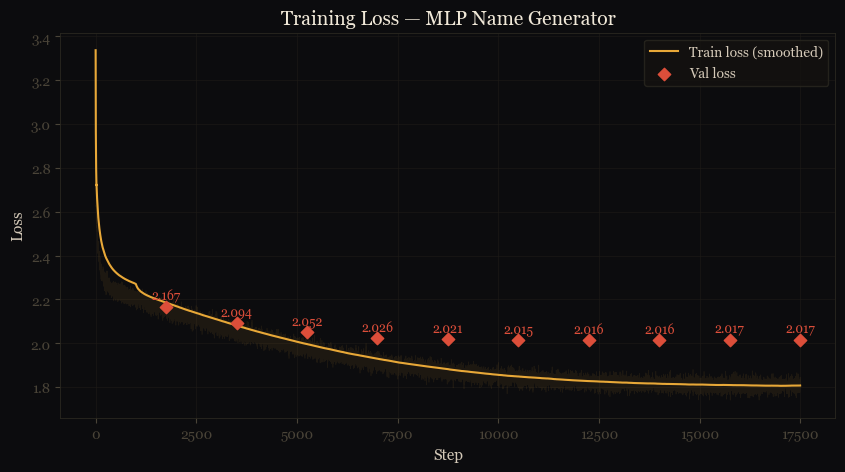

In [12]:
# Training loss curve
fig, ax = plt.subplots(figsize=(10, 5))

steps = range(len(loss_per_itrn))
ax.plot(steps, loss_per_itrn, color=bks.COLORS["amber"], alpha=0.08, linewidth=0.5)

# Windowed moving average — O(n) via prefix sums
window = 1000
arr    = np.asarray(loss_per_itrn)
csum   = np.concatenate(([0.0], np.cumsum(arr)))
idx    = np.arange(len(arr))
lo     = np.maximum(0, idx - window)
smoothed = (csum[idx + 1] - csum[lo]) / (idx + 1 - lo)
ax.plot(steps, smoothed, color=bks.COLORS["amber"], linewidth=1.5, label="Train loss (smoothed)")

ax.scatter(val_steps, val_losses, color=bks.COLORS["red"], s=40, zorder=5,
           marker="D", label="Val loss")
for s, v in zip(val_steps, val_losses):
    ax.text(s, v + 0.03, f"{v:.3f}", ha="center", fontsize=9, color=bks.COLORS["red"])

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training Loss — MLP Name Generator")
ax.legend()
plt.show()

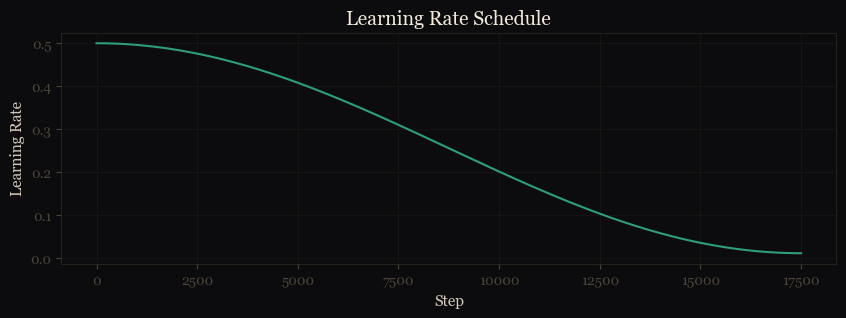

In [13]:
# Learning rate schedule
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(len(lr_per_itrn)), lr_per_itrn, color=bks.COLORS["teal"], linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
plt.show()

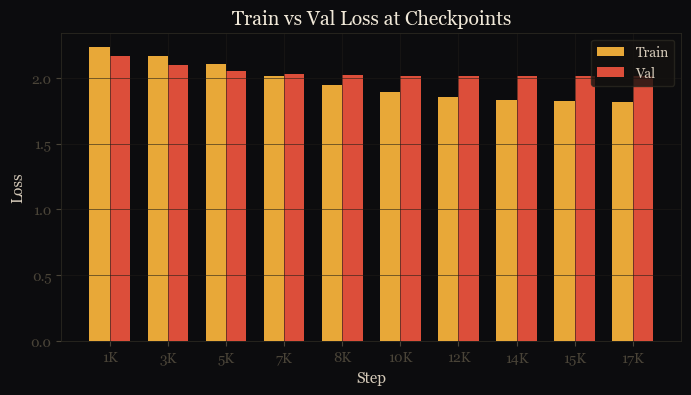

In [14]:
# Train vs val loss at checkpoints
trn_at_checkpoints = []
for s in val_steps:
    w = max(0, s - 5000)
    trn_at_checkpoints.append(sum(loss_per_itrn[w:s]) / (s - w))

fig, ax = plt.subplots(figsize=(8, 4))
x_pos, bar_w = range(len(val_steps)), 0.35
ax.bar([p - bar_w / 2 for p in x_pos], trn_at_checkpoints, bar_w, color=bks.COLORS["amber"], label="Train")
ax.bar([p + bar_w / 2 for p in x_pos], val_losses,         bar_w, color=bks.COLORS["red"],   label="Val")
ax.set_xticks(list(x_pos))
ax.set_xticklabels([f"{s // 1000}K" for s in val_steps])
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Train vs Val Loss at Checkpoints")
ax.legend()
plt.show()

## Evaluation

In [15]:
with torch.no_grad():
    emb     = embed_inputs(trn_inputs)
    h       = torch.tanh(emb.view(-1, d1) @ weights_1 + bias_1)
    trn_loss = torch.nn.functional.cross_entropy(h @ weights_2 + bias_2, trn_outputs)

    test_emb     = embed_inputs(test_inputs)
    test_h       = torch.tanh(test_emb.view(-1, d1) @ weights_1 + bias_1)
    test_loss = torch.nn.functional.cross_entropy(test_h @ weights_2 + bias_2, test_outputs)

print(f"Train: {trn_loss.item():.4f} | Val: {val_losses[-1]:.4f} | Test: {test_loss.item():.4f}")

Train: 1.8075 | Val: 2.0172 | Test: 2.0100


## Sampling

In [16]:
for _ in range(len(words)):
    context = [0] * block_size
    name    = []

    while True:
        emb    = embedding_matrix[torch.tensor([context])]
        h      = torch.tanh(emb.view(1, -1) @ weights_1 + bias_1)
        logits = h @ weights_2 + bias_2
        probs  = torch.softmax(logits, dim=1)
        idx    = torch.multinomial(probs, num_samples=1).item()

        if idx == 0:
            break
        name.append(idx_to_ltr[idx])
        context = context[1:] + [idx]

    print("".join(name))

elyssia
brisley
dayinu
dalen
marquist
brechon
kennaber
mia
aisylus
lazley
hannie
madiava
avalinna
scitaa
zaeli
katino
tanora
aysin
reigan
odesha
chas
rhyzed
bright
azarah
charliek
japlee
maleeia
blayton
mehra
kaelanee
manor
torx
brohis
annorah
ruhi
johnt
abid
ryklum
davirah
maveriah
kairon
alphmarren
beakit
anai
herion
leonna
junuce
youanna
makel
dakshitha
dibhik
caleah
sameera
gravion
kayla
channah
maliki
kavared
kennen
findjan
joseth
avan
sulton
javy
balt
vaterika
zynell
gaster
victitla
dionner
everett
rayman
indimali
chanel
ryon
topio
audrey
yehnain
zahariya
micaya
faro
javory
edhan
sewn
alizey
lyra
yahlie
kamyran
anil
landa
lunabelle
chytan
aryanna
treyja
rahland
angarloue
siah
emerlah
amarean
braiya
eeizer
terris
adenza
ronav
jaleia
alexice
ennlee
xoluwa
shahna
beam
hermue
hondae
abburie
tolowane
ozton
yadin
yoshi
riiyan
deskini
janaye
lamker
cohamoskuk
evelin
lorella
hashi
tayma
hazul
avanni
demonte
aqbari
shaniyah
judasha
abbrees
antola
loche
bezerie
yambrie
jamiene
bowhon
olova